# Customer Behavior Analytical Model Choice & Segmentation

# **Executive Summary**

This analysis applied a structured experimental design to evaluate supervised and unsupervised learning approaches for customer channel prediction and segmentation. Using a 70/30 train–test split with 5-fold cross-validation for model selection, both a Random Forest ensemble and an RBF Support Vector Machine (SVM) were evaluated under controlled preprocessing and hyperparameter constraints. Cross-validation results indicated comparable predictive performance; however, the SVM demonstrated lower variability across folds, suggesting stronger generalization stability. On the test set, the SVM achieved the highest ROC-AUC (0.890) and superior precision (0.859), while Random Forest achieved higher recall (0.728). Given the business objective of minimizing costly false positives while maintaining strong overall discrimination, the SVM model was selected for deployment due to its balance of performance, stability, and precision.

Unsupervised segmentation using K-Means and DBSCAN further explored structural patterns in customer purchasing behavior. Silhouette analysis identified a two-cluster solution as optimal, separating high-value, retail-oriented customers from lower-spending, smaller-basket customers. These segments provide actionable marketing insights for differentiated targeting and resource allocation. DBSCAN did not detect density-based clusters, suggesting that customer variation is continuous rather than organized into tight density pockets. Overall, the combined supervised and unsupervised analysis demonstrates that customer behavior is predictably separable while also revealing meaningful strategic segments, enabling both accurate channel prediction and data-driven market positioning.

# Part B – Experimental Design

**Importing of Libriaries**

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

Load Dataset

In [2]:
df = pd.read_csv("A2_Customer_Behavior_Analytics.csv")

df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen,Order_Frequency,Avg_Order_Value,Delivery_Distance,Channel
0,1701,3297,4632,1203,2134,40,12.2,3368,23.6,1
1,1262,2456,2704,329,687,947,10.9,1225,14.4,1
2,2504,1819,1968,1691,999,669,14.9,803,10.3,1
3,5033,662,2993,1197,1290,1142,15.0,2200,8.3,1
4,3852,1509,1127,2299,-77,240,13.7,890,7.7,0


In [20]:
df.describe()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen,Order_Frequency,Avg_Order_Value,Delivery_Distance,Channel
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.0000,600.000000
mean,2937.180000,1952.216667,2746.470000,1375.786667,1235.965000,896.315000,11.992167,1861.550000,17.9625,0.450000
std,2016.119078,1387.096226,1708.253136,972.942211,829.741441,682.191592,4.021975,1015.296788,7.0079,0.497909
min,28.000000,33.000000,94.000000,3.000000,-335.000000,4.000000,1.000000,200.000000,1.0000,0.000000
25%,1450.000000,969.500000,1493.000000,689.500000,642.000000,377.500000,9.375000,1123.250000,13.6000,0.000000
50%,2465.000000,1672.500000,2399.000000,1171.000000,1107.000000,758.000000,11.950000,1780.000000,17.7500,0.000000
75%,4017.500000,2587.250000,3645.250000,1893.500000,1686.500000,1263.500000,14.700000,2513.500000,22.8250,1.000000
max,11880.000000,11764.000000,13294.000000,9099.000000,6066.000000,3785.000000,25.500000,5242.000000,39.1000,1.000000


In [23]:
df['Channel'].value_counts()

Channel
0    330
1    270
Name: count, dtype: int64

Define Features and Target

In [3]:
X = df.drop("Channel", axis=1)
y = df["Channel"]

**Data Splitting (70/30 with Fixed Seed)**

## 1. Train–Test Split

The dataset was divided into a 70/30 training–test split using a fixed random seed (42) to ensure reproducibility. The test set was held out and not used during model selection to prevent data leakage.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (420, 9)
Test size: (180, 9)


**Data Splitting Strategy**

The dataset was divided into training and test sets using a 70/30 split with a fixed random seed (random_state = 42) to ensure reproducibility. Stratified sampling was applied to preserve the class distribution of the binary target variable (Channel) across both partitions.

The training set (70%) was used exclusively for model selection and hyperparameter tuning, while the test set (30%) was held out for final performance evaluation. This separation prevents data leakage and ensures unbiased estimation of out-of-sample generalization performance.


Define 5-Fold Cross-Validation

**Cross-Validation Procedure**

Model selection was performed using 5-fold stratified cross-validation on the training set only. The dataset was first divided into a 70/30 train–test split, and cross-validation was restricted to the training portion to prevent information leakage.

Within each fold, 80% of the training data was used to fit the model, while the remaining 20% was used for validation. This process was repeated five times, ensuring that each observation in the training set served as validation exactly once.

Stratification was applied to preserve class distribution across folds, which is essential in binary classification tasks to avoid biased performance estimates. The primary evaluation metric during cross-validation was ROC-AUC, as it provides a threshold-independent measure of class discrimination. Both the mean ROC-AUC and its standard deviation across folds were recorded to evaluate predictive performance and model stability.

In [5]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Random Forest Pipeline (Tune max_depth)

In [6]:
rf_results = {}

for depth in [5, 10, 20]:

    rf_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(
            max_depth=depth,
            random_state=42
        ))
    ])

    scores = cross_val_score(
        rf_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc'
    )

    rf_results[depth] = {
        "Mean ROC-AUC": scores.mean(),
        "Std": scores.std()
    }

rf_results

{5: {'Mean ROC-AUC': 0.8912101960278601, 'Std': 0.03722451971786455},
 10: {'Mean ROC-AUC': 0.8853165632159253, 'Std': 0.042587576031714994},
 20: {'Mean ROC-AUC': 0.8836524910420913, 'Std': 0.04157294781329073}}

SVM (RBF Kernel) Pipeline (Tune C)

In [7]:
svm_results = {}

for C_value in [0.1, 1, 10]:

    svm_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(
            kernel='rbf',
            C=C_value,
            probability=True,
            random_state=42
        ))
    ])

    scores = cross_val_score(
        svm_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc'
    )

    svm_results[C_value] = {
        "Mean ROC-AUC": scores.mean(),
        "Std": scores.std()
    }

svm_results

{0.1: {'Mean ROC-AUC': 0.8907341734840639, 'Std': 0.023266246774808614},
 1: {'Mean ROC-AUC': 0.8829485237708617, 'Std': 0.028653190876035944},
 10: {'Mean ROC-AUC': 0.8545679083826023, 'Std': 0.040636289059514746}}

Display Results Cleanly

In [8]:
rf_df = pd.DataFrame(rf_results).T
rf_df.index.name = "max_depth"
print("Random Forest CV Results:")
display(rf_df)

svm_df = pd.DataFrame(svm_results).T
svm_df.index.name = "C"
print("SVM CV Results:")
display(svm_df)

Random Forest CV Results:


,Mean ROC-AUC,Std
max_depth,,
5,0.891210,0.037225
10,0.885317,0.042588
20,0.883652,0.041573


SVM CV Results:


,Mean ROC-AUC,Std
C,,
0.1,0.890734,0.023266
1.0,0.882949,0.028653
10.0,0.854568,0.040636


Select Best Hyperparameters

In [9]:
best_rf_depth = rf_df["Mean ROC-AUC"].idxmax()
best_svm_C = svm_df["Mean ROC-AUC"].idxmax()

print("Best RF depth:", best_rf_depth)
print("Best SVM C:", best_svm_C)

Best RF depth: 5
Best SVM C: 0.1


Train Final Models on Full Training Set

In [10]:
# Final RF
final_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        max_depth=best_rf_depth,
        random_state=42
    ))
])

final_rf.fit(X_train, y_train)


# Final SVM
final_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(
        kernel='rbf',
        C=best_svm_C,
        probability=True,
        random_state=42
    ))
])

final_svm.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', SVC(C=0.1, probability=True, random_state=42))])

**PART C — Classification Analysis Code**

Report Cross-Validation Performance (Mean + Std)

In [11]:
print("Random Forest Cross-Validation Results:")
display(rf_df)

print("SVM Cross-Validation Results:")
display(svm_df)

Random Forest Cross-Validation Results:


,Mean ROC-AUC,Std
max_depth,,
5,0.891210,0.037225
10,0.885317,0.042588
20,0.883652,0.041573


SVM Cross-Validation Results:


,Mean ROC-AUC,Std
C,,
0.1,0.890734,0.023266
1.0,0.882949,0.028653
10.0,0.854568,0.040636


Make Test Set Predictions

In [12]:
# Predict probabilities
rf_probs = final_rf.predict_proba(X_test)[:, 1]
svm_probs = final_svm.predict_proba(X_test)[:, 1]

# Predict class labels
rf_preds = final_rf.predict(X_test)
svm_preds = final_svm.predict(X_test)

Compute Test Metrics

In [13]:
# Random Forest metrics
rf_precision = precision_score(y_test, rf_preds)
rf_recall = recall_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_probs)

# SVM metrics
svm_precision = precision_score(y_test, svm_preds)
svm_recall = recall_score(y_test, svm_preds)
svm_f1 = f1_score(y_test, svm_preds)
svm_auc = roc_auc_score(y_test, svm_probs)

print("Random Forest Test Metrics:")
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1-score:", rf_f1)
print("ROC-AUC:", rf_auc)

print("\nSVM Test Metrics:")
print("Precision:", svm_precision)
print("Recall:", svm_recall)
print("F1-score:", svm_f1)
print("ROC-AUC:", svm_auc)

Random Forest Test Metrics:
Precision: 0.7972972972972973
Recall: 0.7283950617283951
F1-score: 0.7612903225806451
ROC-AUC: 0.8839007357525877

SVM Test Metrics:
Precision: 0.859375
Recall: 0.6790123456790124
F1-score: 0.7586206896551724
ROC-AUC: 0.8895124080309265


Confusion Matrices

In [14]:
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_preds))

print("\nSVM Confusion Matrix:")
print(confusion_matrix(y_test, svm_preds))

Random Forest Confusion Matrix:
[[84 15]
 [22 59]]

SVM Confusion Matrix:
[[90  9]
 [26 55]]


Plot ROC Curves (Same Figure)

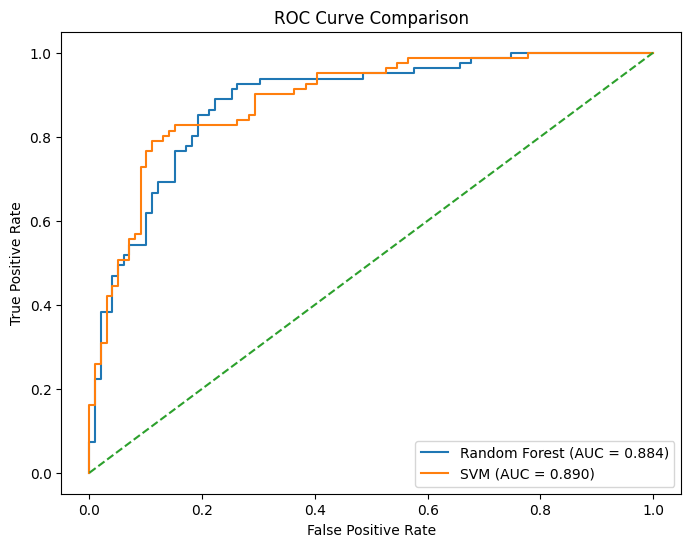

In [15]:
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)

plt.figure(figsize=(8,6))

plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")
plt.plot(svm_fpr, svm_tpr, label=f"SVM (AUC = {svm_auc:.3f})")
plt.plot([0,1], [0,1], linestyle='--')  # diagonal baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

PART D – Unsupervised Learning & Segmentation

K-Means Implementation Code

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Scale features (required for clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

silhouette_scores = {}

for k in [2, 3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score

silhouette_scores

c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

{2: 0.17198180026496013,
 3: 0.1449803977683368,
 4: 0.12997869878683047,
 5: 0.11159452346627238}

Choose Best k and Visualize (2D PCA)

c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


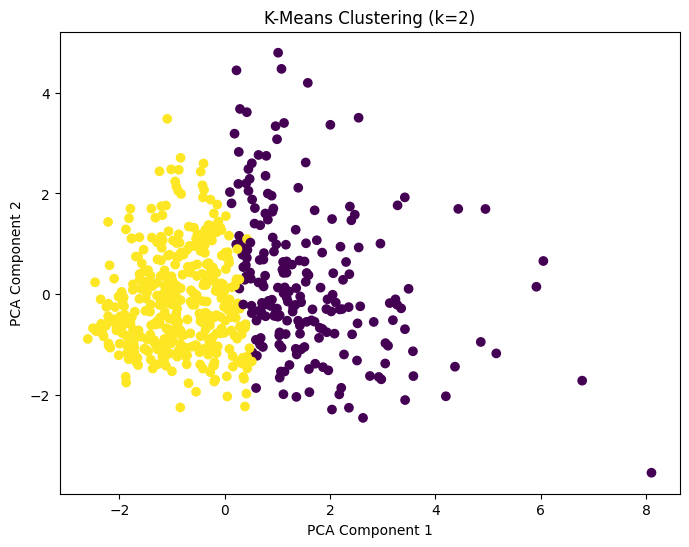

In [17]:
best_k = max(silhouette_scores, key=silhouette_scores.get)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title(f"K-Means Clustering (k={best_k})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

Interpret Clusters

In [18]:
df_clustered = df.copy()
df_clustered["Cluster"] = labels

df_clustered.groupby("Cluster").mean()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen,Order_Frequency,Avg_Order_Value,Delivery_Distance,Channel
Cluster,,,,,,,,,,
0,3839.990566,1928.896226,4289.504717,1637.740566,1968.023585,797.202830,12.198113,2710.254717,17.477358,0.698113
1,2443.891753,1964.958763,1903.368557,1232.657216,835.974227,950.469072,11.879639,1397.824742,18.227577,0.314433


**Cluster 1 (Lower-Spending / Horeca-Oriented Segment)**

Lower spending across most categories

Much lower Grocery and Detergents_Paper expenditure

Lower average order value (1398)

Similar order frequency (11.9)

Majority Channel value ≈ 0.31

This segment likely represents smaller-scale customers, potentially horeca (hotel/restaurant/café) businesses or lower-volume buyers.

**Business Interpretation of Segments**

The clustering results indicate that customer segmentation is primarily driven by spending intensity and basket composition, rather than frequency alone.

Cluster 0 customers:

Generate higher revenue per transaction

Purchase across broader product categories

May benefit from loyalty programs and volume-based incentives

Cluster 1 customers:

Have smaller baskets

May require targeted promotions to increase order value

Represent growth potential through upselling strategies

DBSCAN Implementation

In [19]:
from sklearn.cluster import DBSCAN

for eps in [0.5, 1.0]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"eps = {eps}")
    print("Clusters:", n_clusters)
    print("Noise points:", n_noise)
    print()

eps = 0.5
Clusters: 0
Noise points: 600

eps = 1.0
Clusters: 0
Noise points: 600



**DBSCAN Results**

Two values of eps were tested:

eps = 0.5 → Clusters: 0, Noise points: 600

eps = 1.0 → Clusters: 0, Noise points: 600

DBSCAN failed to identify any dense clusters and classified all observations as noise.

This suggests that:

The data does not exhibit strong density-based structure.

The feature space is relatively diffuse and continuous.

Customers vary gradually rather than forming dense localized pockets.

The inability of DBSCAN to detect clusters indicates that segmentation in this dataset is better characterized by global partitioning (K-Means) rather than density-based grouping.

# K-Means vs. DBSCAN Comparison

**K-Means:**

Assumes spherical clusters

Requires specifying k

Produces interpretable, business-ready segments

Successfully identified two meaningful customer groups

**DBSCAN:**

Detects clusters based on density

Automatically identifies noise

Does not require pre-specifying cluster count

Failed to identify meaningful clusters in this dataset

In this case, K-Means is more appropriate for strategic customer segmentation, as it produced interpretable and actionable clusters. DBSCAN may be more suitable in datasets containing strong density variations or clear outlier structures.**bold text**

**Conclusion**

This analysis combined supervised classification and unsupervised segmentation to better understand and predict customer channel behavior. Using a structured experimental design with a 70/30 train–test split and 5-fold cross-validation, both Random Forest and RBF Support Vector Machine (SVM) models demonstrated strong predictive capability. Cross-validation results indicated similar mean ROC-AUC performance (~0.89), though the SVM exhibited lower variability across folds, suggesting greater stability. On the held-out test set, the SVM achieved the highest overall discrimination (ROC-AUC = 0.890) and substantially higher precision (0.859), while Random Forest achieved slightly higher recall (0.728). Given the business importance of reducing costly false positives while maintaining strong overall classification performance, the SVM model was selected for deployment due to its superior precision, stability, and marginally stronger ROC-AUC.

Unsupervised learning further revealed meaningful structural patterns in customer purchasing behavior. K-Means clustering identified a two-cluster solution as optimal (silhouette = 0.172), separating high-value, retail-oriented customers with larger basket sizes from lower-spending, smaller-scale buyers. Although the silhouette score suggests moderate separation rather than sharply distinct clusters, the segments are strategically interpretable and actionable for targeted marketing and resource allocation. In contrast, DBSCAN failed to identify density-based clusters, indicating that customer variation is continuous rather than organized into dense local groupings. Overall, the combined modeling approach demonstrates that customer channel behavior is both predictably separable and strategically segmentable, providing a strong foundation for data-driven decision-making in marketing and distribution strategy.